In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END

In [2]:
def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "hello world"}]}
#This is a graph node.
# node can call llm or do any other logic, as long as it receives state and returns state.
# A node is just a Python function that receives the current state and returns updated state.
graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

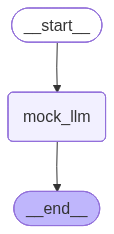

In [3]:
# Draw Mermaid PNG using LangGraph
# This may require internet access depending on your LangGraph rendering method/environment.

from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()
with open("langgraph_mock_llm_graph.png", "wb") as f:
    f.write(png_data)

display(Image(png_data))

In [4]:
res = graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})
print(res)

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='0261a185-e17a-40de-a71b-d305815b5a93'), AIMessage(content='hello world', additional_kwargs={}, response_metadata={}, id='4fb14ba3-0f0d-4434-8b8e-66ae6f696155', tool_calls=[], invalid_tool_calls=[])]}
